Simulation starting for Aluminum 6061-T6...
Simulation complete. Plotting the graph...


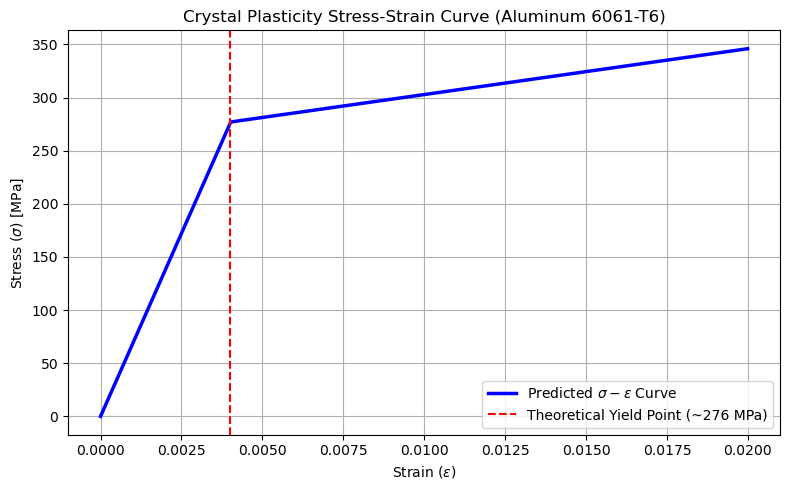

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Material and Test Parameters (Aluminum 6061-T6) ---
E = 68900.0            # Elastic modulus (MPa) [Callister & Rethwisch, 2018]
M = 3.07               # Taylor Factor (FCC) [Zhang et al., 2019]
tau_0 = 276.0 / M      # Initial critical resolved shear stress (MPa) ~ 89.9 MPa
dt = 0.01              # Time step (seconds)
strain_rate = 0.001    # Applied strain rate (1/s)
total_strain = 0.02    # Total strain to reach (2%)

# --- Physical Parameters ---
B = 1e-4               # Dislocation drag coefficient (Pa.s) [Kumar et al., 1968]
rho = 1e13             # Dislocation density (1/m^2) [Lee et al., 1999]
b = 2.86e-10           # Burgers vector for Aluminum (m) [Reyes-Ruiz et al., 2015]

# Total number of simulation steps
time_steps = int(total_strain / (strain_rate * dt))

# Arrays to store the history of variables for plotting
strain_history = [0.0]
stress_history = [0.0]

# Initial states
sigma_current = 0.0
strain_current = 0.0
g_resistance = tau_0   

print("Simulation starting for Aluminum 6061-T6...")

# --- DEFORMATION LOOP ---
for step in range(time_steps):
    # Total strain increment for this time step
    d_eps_total = strain_rate * dt
    strain_current += d_eps_total
    
    # Iteration settings for the self-consistent loop
    tolerance = 1e-8
    error = 1.0
    max_iters = 100
    iters = 0
    
    # Initial guess: Assume all deformation in this step is purely elastic
    d_eps_e_guess = d_eps_total 
    
    # --- SELF-CONSISTENT ITERATIVE PROCESS (Fixed-Point Iteration) ---
    while error > tolerance and iters < max_iters:
        iters += 1
        
        # 1. Calculate trial stress (Hooke's Law)
        d_sigma = E * d_eps_e_guess
        sigma_trial = sigma_current + d_sigma
        
        # 2. Calculate excess stress
        tau_trial = abs(sigma_trial) / M  # Resolved shear stress
        excess_stress = tau_trial - g_resistance
        
        # 3. Calculate plastic strain
        if excess_stress <= 0:
            # Below yield point, purely elastic behavior
            d_eps_p_calc = 0.0
        else:
            # Orowan equation for plastic flow
            gamma_dot = rho * b * ((excess_stress * b) / B)
            d_eps_p_calc = (gamma_dot * dt) / M
            
        # 4. New elastic strain estimate (Total = Elastic + Plastic)
        d_eps_e_new = d_eps_total - d_eps_p_calc
        
        # Calculate error between iterations
        error = abs(d_eps_e_new - d_eps_e_guess)
        
        # 5. Correction step (Relaxation to ensure stability)
        d_eps_e_guess = 0.5 * d_eps_e_guess + 0.5 * d_eps_e_new

    # Iteration converged successfully! Update the main variables
    sigma_current += E * d_eps_e_guess
    
    # Strain Hardening Model [Lee et al., 1999]
    # As dislocations accumulate, resistance to further deformation increases
    g_resistance += 1500.0 * d_eps_p_calc 
    
    # Store values for plotting
    strain_history.append(strain_current)
    stress_history.append(sigma_current)

print("Simulation complete. Plotting the graph...")

# --- PLOTTING ---
plt.figure(figsize=(8, 5))
plt.plot(strain_history, stress_history, 'b-', linewidth=2.5, label='Predicted $\sigma-\epsilon$ Curve')
plt.axvline(x=(tau_0 * M) / E, color='r', linestyle='--', label=f'Theoretical Yield Point (~{tau_0 * M:.0f} MPa)') 
plt.xlabel('Strain ($\epsilon$)')
plt.ylabel('Stress ($\sigma$) [MPa]')
plt.title('Crystal Plasticity Stress-Strain Curve (Aluminum 6061-T6)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()